In [11]:
# ── 1. KÜTÜPHANELER ───────────────────────────────────────────────────────────

import os
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Mixed precision: float16 hesaplama, float32 ağırlık → VRAM yarıya iner
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print(f"TensorFlow versiyon : {tf.__version__}")
print(f"GPU'lar             : {tf.config.list_physical_devices('GPU')}")

# ─────────────────────────────────────────────────────────────────────────────

TensorFlow versiyon : 2.10.0
GPU'lar             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:


# ── 2. AYARLAR ────────────────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent
DATA_DIR    = BASE_DIR / "data"
CLASSES     = ["H1", "H2", "H3", "H5", "H6"]
NUM_CLASSES = len(CLASSES)

IMG_SIZE        = (300, 300)
BATCH_SIZE      = 8
EPOCHS_FROZEN   = 10    # Backbone dondurulmuş; sadece head
EPOCHS_FINETUNE = 20    # Kısmi fine-tune; son 100 katman açık
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4


In [13]:

# ── 3. VERİ YÜKLEYİCİLER ─────────────────────────────────────────────────────

train_ds = image_dataset_from_directory(
    DATA_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

valid_ds = image_dataset_from_directory(
    DATA_DIR / "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# ─────────────────────────────────────────────────────────────────────────────


Found 4780 files belonging to 5 classes.
Found 1022 files belonging to 5 classes.
Found 1029 files belonging to 5 classes.


In [14]:

## Sınıf Dağılımları

splits = {"Train": DATA_DIR / "train", "Valid": DATA_DIR / "valid", "Test": DATA_DIR / "test"}

header = f"{'Sınıf':<8}" + "".join(f"{name:>10}" for name in splits)
print(header)
print("-" * (8 + 10 * len(splits)))

totals = {name: 0 for name in splits}
for cls in CLASSES:
    row = f"{cls:<8}"
    for name, path in splits.items():
        count = len(list((path / cls).glob("*.*")))
        totals[name] += count
        row += f"{count:>10}"
    print(row)

print("-" * (8 + 10 * len(splits)))
print(f"{'TOPLAM':<8}" + "".join(f"{totals[n]:>10}" for n in splits))

Sınıf        Train     Valid      Test
--------------------------------------
H1            1311       281       282
H2            1039       222       224
H3             814       174       175
H5             819       175       176
H6             797       170       172
--------------------------------------
TOPLAM        4780      1022      1029


In [15]:
# ── 4. VERİ ARTIRMA (AUGMENTATION) ───────────────────────────────────────────

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")

# ─────────────────────────────────────────────────────────────────────────────


In [16]:
# ── 5. MODEL — TRANSFER LEARNING (EfficientNetB3) ────────────────────────────

def build_model(trainable_base=False):
    base = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    # EfficientNet kendi içinde normalizasyon yapar; ham [0,255] piksel verilir
    x = base(x, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    return keras.Model(inputs, outputs), base

# ─────────────────────────────────────────────────────────────────────────────


In [17]:

def make_callbacks(save_path):
    return [
        keras.callbacks.ModelCheckpoint(
            save_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,  # JSON serileştirme sorununu önler
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


In [18]:
# ── 7. AŞAMA 1 — DONUK BACKBONE, SADECE HEAD EĞİTİMİ ────────────────────────


print("\n=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===")

model, base_model = build_model(trainable_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary(show_trainable=True)

history_frozen = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=make_callbacks("best_model_efficientnetb3_head.weights.h5"),
)


# ─────────────────────────────────────────────────────────────────────────────



=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===
Model: "model_1"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_4 (InputLayer)        [(None, 300, 300, 3)]     0         Y          
                                                                            
 augmentation (Sequential)   (None, 300, 300, 3)       0         Y          
                                                                            
 efficientnetb3 (Functional)  (None, 10, 10, 1536)     10783535  N          
                                                                            
 global_average_pooling2d_1   (None, 1536)             0         Y          
 (GlobalAveragePooling2D)                                                   
                                                                            
 dropout_1 (Dropout)         (None, 1536)              0         Y          
     

In [19]:
# ── 8. AŞAMA 2 — KISMİ FINE-TUNE (son 100 katman) ───────────────────────────

print("\n=== AŞAMA 2: Kısmi Fine-Tune (son 100 katman açık) ===")

# save_weights_only=True kullandığımız için modeli yeniden inşa edip ağırlık yüklüyoruz
model, _ = build_model(trainable_base=False)
model.load_weights("best_model_efficientnetb3_head.weights.h5")
for layer in model.layers:
    layer.trainable = False

for layer in model.layers[-100:]:
    layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Açık katman sayısı: {trainable_count} / {len(model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=make_callbacks("best_model_efficientnetb3.h5"),
)


=== AŞAMA 2: Kısmi Fine-Tune (son 100 katman açık) ===
Açık katman sayısı: 6 / 6
Epoch 1/20
598/598 [==============================] - ETA: 0s - loss: 0.7429 - accuracy: 0.7004
Epoch 1: val_loss improved from inf to 0.62452, saving model to best_model_efficientnetb3.h5
598/598 [==============================] - 431s 675ms/step - loss: 0.7429 - accuracy: 0.7004 - val_loss: 0.6245 - val_accuracy: 0.7476 - lr: 1.0000e-04
Epoch 2/20
598/598 [==============================] - ETA: 0s - loss: 0.5513 - accuracy: 0.7828
Epoch 2: val_loss improved from 0.62452 to 0.48175, saving model to best_model_efficientnetb3.h5
598/598 [==============================] - 400s 669ms/step - loss: 0.5513 - accuracy: 0.7828 - val_loss: 0.4817 - val_accuracy: 0.8043 - lr: 1.0000e-04
Epoch 3/20
598/598 [==============================] - ETA: 0s - loss: 0.4574 - accuracy: 0.8155
Epoch 3: val_loss improved from 0.48175 to 0.44915, saving model to best_model_efficientnetb3.h5
598/598 [==============================

In [1]:
# ── 10. LOSS / ACCURACY GRAFİKLERİ ───────────────────────────────────────────

import matplotlib.pyplot as plt

def plot_history(frozen_hist, finetune_hist):
    train_loss = frozen_hist.history["loss"]         + finetune_hist.history["loss"]
    val_loss   = frozen_hist.history["val_loss"]     + finetune_hist.history["val_loss"]
    train_acc  = frozen_hist.history["accuracy"]     + finetune_hist.history["accuracy"]
    val_acc    = frozen_hist.history["val_accuracy"] + finetune_hist.history["val_accuracy"]

    epochs     = range(1, len(train_loss) + 1)
    frozen_end = len(frozen_hist.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, train_loss, label="Train Loss")
    ax1.plot(epochs, val_loss,   label="Val Loss")
    ax1.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_acc, label="Train Accuracy")
    ax2.plot(epochs, val_acc,   label="Val Accuracy")
    ax2.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.suptitle("EfficientNetB3 — Eğitim Geçmişi", fontsize=14)
    plt.tight_layout()
    plt.savefig("training_history_efficientnetb3.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → training_history_efficientnetb3.png")

plot_history(history_frozen, history_finetune)

NameError: name 'history_frozen' is not defined

In [2]:
# ── 9. TEST DEĞERLENDİRMESİ ───────────────────────────────────────────────────

print("\n=== Test Değerlendirmesi ===")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
best_model, _ = build_model(trainable_base=False)
best_model.load_weights(Path.cwd() / "best_model_efficientnetb3.h5")
best_model.compile(loss="categorical_crossentropy", metrics=["accuracy"])
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


=== Test Değerlendirmesi ===


NameError: name 'tf' is not defined

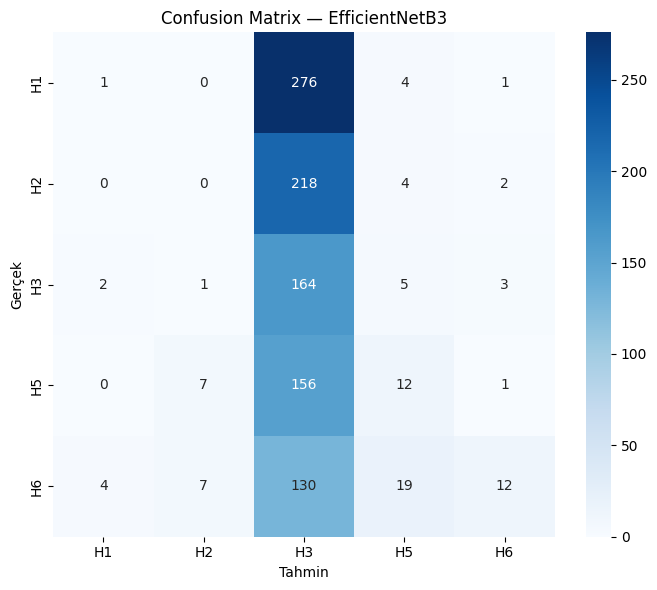

Graf kaydedildi → confusion_matrix_efficientnetb3.png


In [22]:
# ── 11. CONFUSION MATRIX ──────────────────────────────────────────────────────


import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataset, class_names):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
    ax.set_title("Confusion Matrix — EfficientNetB3")
    plt.tight_layout()
    plt.savefig("confusion_matrix_efficientnetb3.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → confusion_matrix_efficientnetb3.png")

    return y_true, y_pred

y_true, y_pred = plot_confusion_matrix(best_model, test_ds, CLASSES)

# ───

In [23]:
# ── 12. CLASSIFICATION REPORT ─────────────────────────────────────────────────

from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

          H1     0.1429    0.0035    0.0069       282
          H2     0.0000    0.0000    0.0000       224
          H3     0.1737    0.9371    0.2931       175
          H5     0.2727    0.0682    0.1091       176
          H6     0.6316    0.0698    0.1257       172

    accuracy                         0.1837      1029
   macro avg     0.2442    0.2157    0.1070      1029
weighted avg     0.2209    0.1837    0.0914      1029

